# Project 2: Social Media

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng()

The above code is solely meant to import NumPy, Pandas, and Matplot libraries into the project. A random number generator (RNG) is also created, to be used for future code.

In [8]:
class Person:
    def __init__(self, person_type):
        self.type = person_type
        self.x = rng.uniform(0,1)
        self.y = rng.uniform(0,1)
        self.happiness_level = False

    def get_location(self):
        return self.x, self.y

    def distance(self, person2):
        distance = np.sqrt((self.x - person2.x)**2 + (self.y - person2.y)**2)
        return distance

    def happiness(self, people):
        distances_list = [(person.type, self.distance(person)) for person in people if person != self]
        distances_list.sort(key=lambda x: x[1])
        close_circle = [True for color, distance in distances_list[:10] if color == self.type]
        if sum(close_circle) >= 5:
            self.happiness_level = True
        else:
            self.happiness_level = False
        return self.happiness_level
    
    def move(self):
        self.x = rng.uniform(0,1)
        self.y = rng.uniform(0,1)
        return (self.x,self.y)

### The `Person` Class:

When creating a Person, the input requires a person_type, which you would put as either 'red' or 'blue' as the Network class does below. The initialization gives us the following attributes:

* `self.type` = the person_type inputted.
* `self.x` = a random number (RNG) uniformly chosen from 0-1. This represents the x value for each person.
* `self.y` = a random number (RNG) uniformly chosen from 0-1. This represents the y value for each person.
* `self.happiness_level` = the happiness of a person, automatically set to False, can be changed in the happiness method.

The `get_location` method requires no input, and simply returns the persons x and y values, denoting their position on the social media graph.

The `distance` method requires an input of another Person. The method then uses the formula for Euclidian distance to determine how far away the inputted Person is to the original Person. This formula inputs self.x, self.y and also person2.x, person2.y, in order to calculate the distance. distance is returned.

The `happiness` method requires an input of a list of more than one person (people). The method then does the following:

1. a list called distances_list is created, which includes a tuple for each person based on the people inputted. The tuple contains the new person's type (red or blue), and the distance from the original person, using self.distance.
2. Then, the list is sorted, such that the people who have the smallest distance are at the beginning of the list, and the largest distance at the end. This will help to understand who our neighbors are.
3. A new list, called close_circle is created, which converts the closest 10 neighbors (the first 10 people on the distances_list) into booleans. If the neighbor has the same color type, they become True, and if not they become False.
4. Finally, an if statement determines the happiness of the person. If 5 or more people in the closest 10 have the same color type, they are happy - self.happiness is changed to equal True. If less than 5 people in the closest 10 are of the same color, they are NOT happy - self.happiness is set equal to False (which is necessary for the Network Class). These calculations are done by summing close_circle to see how many Trues exist. self.happiness is returned.

The `move` method requires no input. The method simply assigns a new x and y value (self.x, self.y) to the person, returning their new state.

In [10]:
class Network:
    def __init__(self, user_number=1200):
        self.user_number = user_number
        self.people = [Person('red') for half in range(int((self.user_number)/2))] + [Person('blue') for half in range(int(self.user_number/2))]
        self.total_happiness = []
        self.counter = 1

    
    def plot(self):
        fig, ax = plt.subplots()
        x_red = [person.x for person in self.people if person.type == 'red']
        y_red = [person.y for person in self.people if person.type == 'red']
        x_blue = [person.x for person in self.people if person.type == 'blue']
        y_blue = [person.y for person in self.people if person.type == 'blue']
        ax.scatter(x_red,y_red, color='red')
        ax.set(title = f'Iteration {self.counter}')
        ax.scatter(x_blue,y_blue, color='blue')
        plt.tight_layout()

    def simulate(self):
        self.plot()
        for person in self.people:
            self.total_happiness.append(person.happiness(self.people))
        while sum(self.total_happiness) < 1200:
            self.total_happiness = []
            for person in self.people: 
                if person.happiness(self.people)==False:
                    person.move()
            for person in self.people:
                self.total_happiness.append(person.happiness(self.people))
            self.counter += 1
            self.plot()

### The `Network` Class

When creating a Network, the only input is the user number, which for the confines of the project, I have set to 1200. Initialization gives us the following attributes:

* `self.user_number` = the user_number inputted
* `self.people` = A list which contains people (using the person class) the number of which corresponding to the user_number. Half are set to red, and half are set to blue when initializing the people.
* `self.total_happiness` = []. This will be used at a later time to represent all people's self.happiness.
* `self.counter` = 1. This will keep track of the iterations used in the simulation method.

The `plot` method requires no input. It does the following:

1. Creates a figure and axes in the form of subplots using plt.subplots()
2. Puts all x and y values for all red and blue people into 4 lists, by returning self.x, self.y and the self.type for every person. 
3. Graphs a scatterplot, which uses x_red, y_red and x_blue, y_blue as the coordinates for either red dots or blue dots. Each number on the x_red list will pair with the matching person's y_red number for example, so that their coordinate is mapped out correctly.
4. The graph is given a title, based on the iteration number as provided by self.counter. plt.tight_layout() makes the graph look better by tightening it.

The `simulate` method requires no input. It does the following:

1. Uses self.plot() to plot the original distribution of points that were created when creating self.people. Each person's x and y value show up as either red or blue depending on their type.
2. For all people in self.people, self.total_happiness is appended in order to find each persons current baseline self.happiness (True or False)
3. A while loop is created, which only stops when the sum of self.total_happiness is equal to 1200. Remember - each person's happiness is either True or False, so when 1200 is reached, all people are True, or happy. If that is not the case, then...
   1. self.total_happiness is set to [], so that the new happiness' are included after simulating.
   2. Then, for every person in self.people -- If self.happiness() is equal to False, meaning that the person is not happy where they are, they will use self.move() in order to find a new place where they might be happy.
   3. Then, again for every person in self.people, everyone's new happiness (self.happiness()) is appended into self.total_happiness in order to assess how happy people are once again now that moving has occurred.
   4. The counter increases, meaning that every person was given the chance to move (one iteration occurred).
   5. The current state of the Network is graphed to show the outcome of the iteration, and the loop either stops, or goes again.


An example of the Network Class is shown below, called Instagram. There are a number of iterations graphed after using the simulation method. The final graph is at the bottom, where every person in the Network is happy.

The final result in the simulation shows a number of "groups" that are made up of the same color-type people. While some groups contain more people than others, its clear that they congregated to be surrounded by the same type. I see this as closer to an echo-chamber, since the blues preferred to be with blues, and the reds preferred other reds. However, if the color represents beliefs, then it wouldn't make sense for reds and blues to be on opposite sides of the plot. Infact there are many people located far apart from groups of their own color type, even though they have the same beliefs. Thus, the actual graph is mixed, not representing a true split of reds and blues.

In [12]:
Instagram = Network()

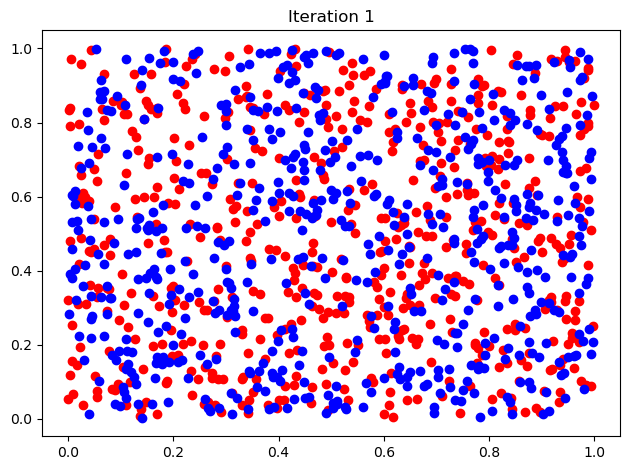

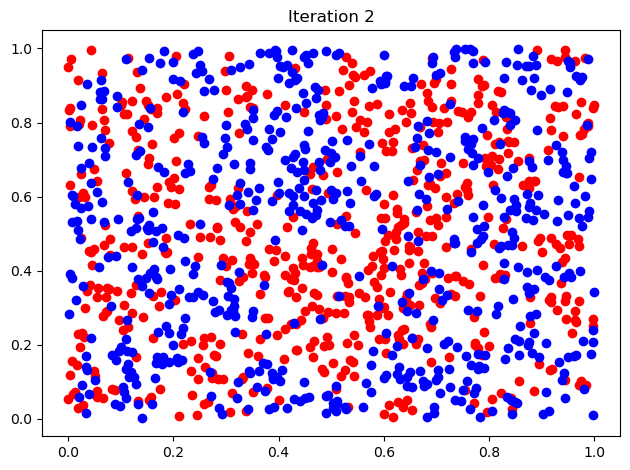

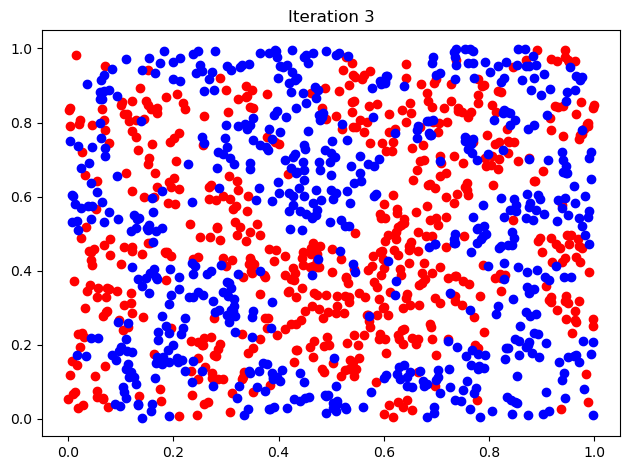

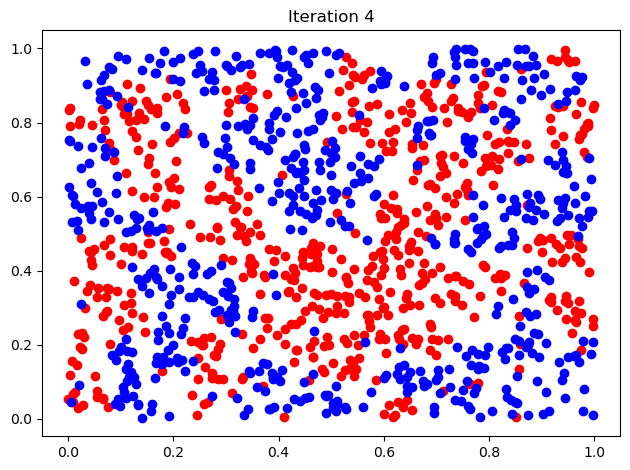

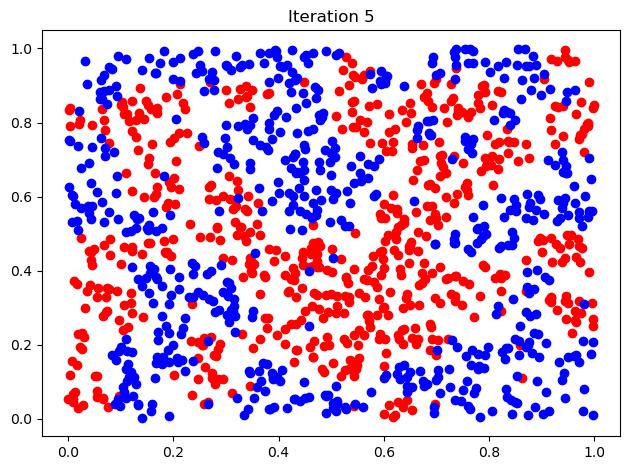

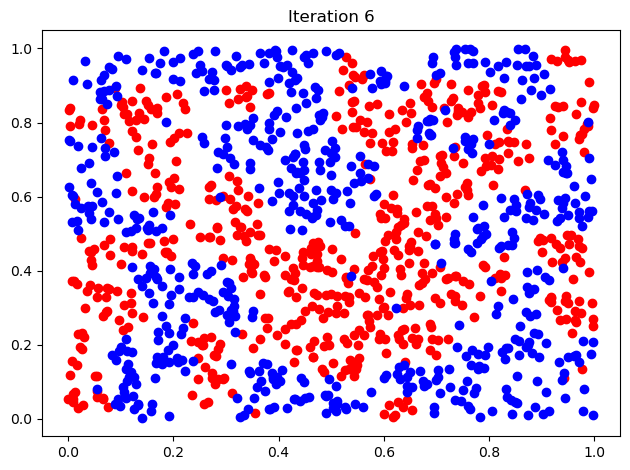

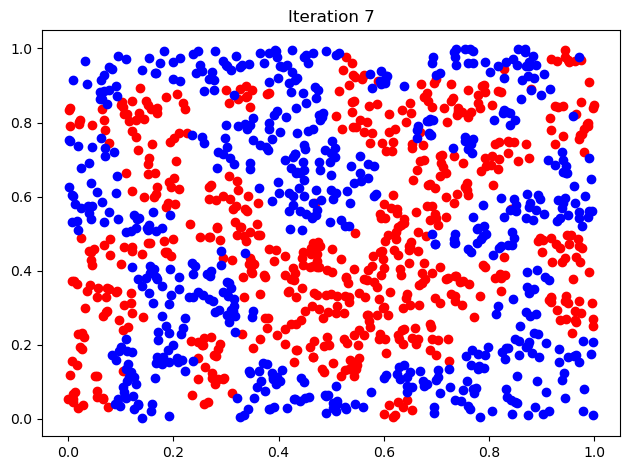

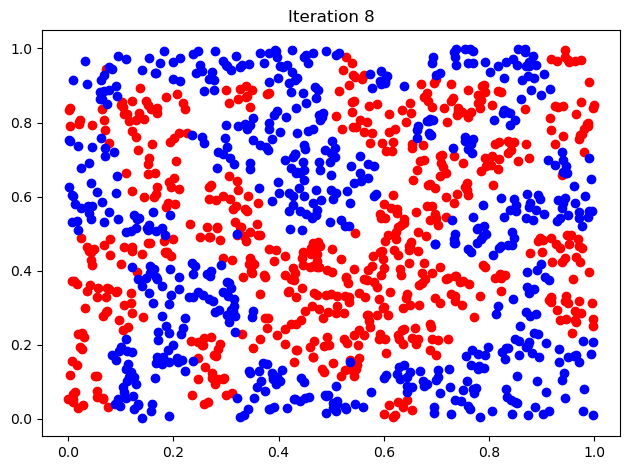

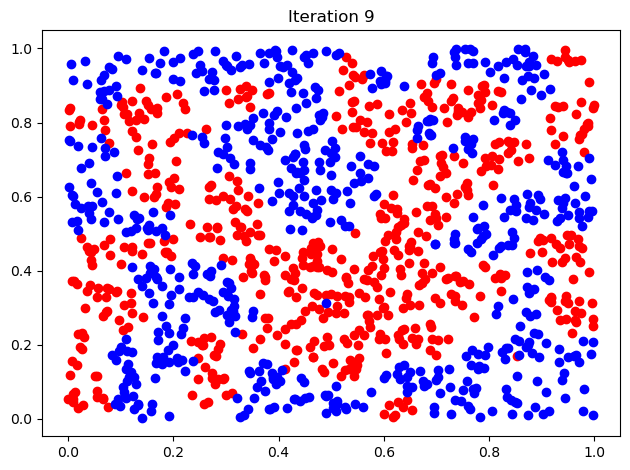

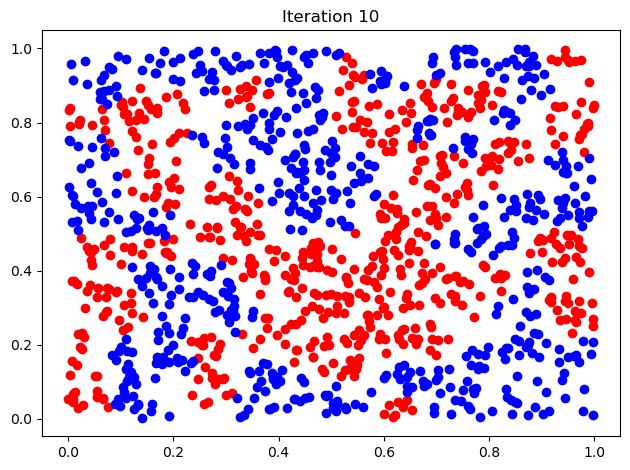

In [13]:
Instagram.simulate()